# Explore Datasets
This notebook visualizes the IDRiD and APTOS 2019 datasets.

In [1]:
import os, sys
# Find project root: walk up from CWD, then try known Kaggle path
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
from src.config import load_config
config = load_config('configs/default.yaml')

In [3]:
# Check if datasets are downloaded
from src.data.download import DatasetDownloader

downloader = DatasetDownloader(data_dir=os.path.join(PROJECT_ROOT, 'data'))
verification = downloader.verify_datasets()

for name, info in verification.items():
    print(f'{name}: {info}')

# Download if needed
if not all(v['exists'] for v in verification.values()):
    print('\nSome datasets missing. Run 00_setup_kaggle.ipynb first.')

idrid: {'exists': True, 'path': '/kaggle/working/medical_CTTA/data/IDRiD', 'has_images': True, 'has_csv': True}
aptos2019: {'exists': True, 'path': '/kaggle/working/medical_CTTA/data/APTOS2019', 'has_images': True, 'has_csv': True}


In [4]:
# Load IDRiD dataset
from src.data.registry import DatasetRegistry

try:
    idrid_class = DatasetRegistry.get('idrid')
    idrid_train = idrid_class(config.source_dataset.data_dir, train=True)
    idrid_test = idrid_class(config.source_dataset.data_dir, train=False)
    
    print(f'IDRiD train size: {len(idrid_train)}')
    print(f'IDRiD test size: {len(idrid_test)}')
except FileNotFoundError as e:
    print(f'IDRiD not found: {e}')

IDRiD train size: 330
IDRiD test size: 83


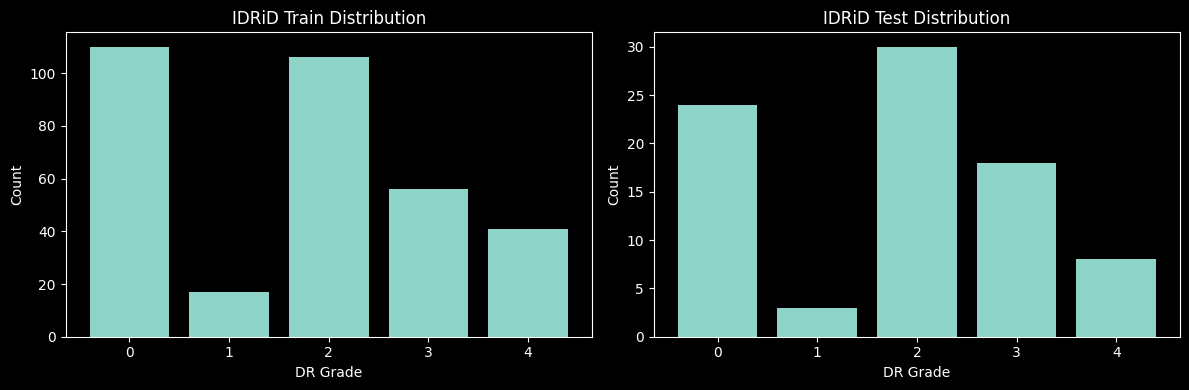

In [5]:
# Visualize IDRiD class distribution
try:
    train_dist = idrid_train.get_class_distribution()
    test_dist = idrid_test.get_class_distribution()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].bar(train_dist.keys(), train_dist.values())
    axes[0].set_title('IDRiD Train Distribution')
    axes[0].set_xlabel('DR Grade')
    axes[0].set_ylabel('Count')
    
    axes[1].bar(test_dist.keys(), test_dist.values())
    axes[1].set_title('IDRiD Test Distribution')
    axes[1].set_xlabel('DR Grade')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
except NameError:
    print('IDRiD dataset not loaded')

In [6]:
# Load APTOS dataset
try:
    aptos_class = DatasetRegistry.get('aptos2019')
    aptos_train = aptos_class(config.target_dataset.data_dir, train=True)
    aptos_test = aptos_class(config.target_dataset.data_dir, train=False)
    
    print(f'APTOS train size: {len(aptos_train)}')
    print(f'APTOS test size: {len(aptos_test)}')
except FileNotFoundError as e:
    print(f'APTOS not found: {e}')

APTOS train size: 2344
APTOS test size: 586


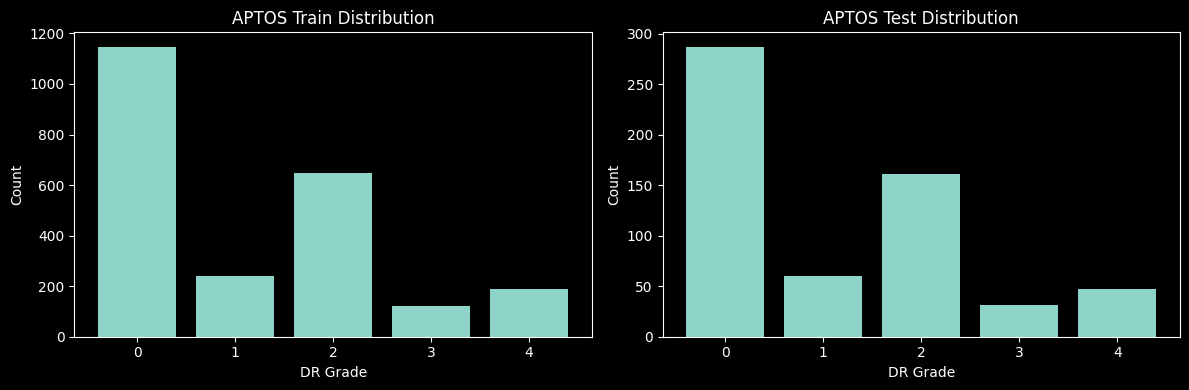

In [7]:
# Visualize APTOS class distribution
try:
    train_dist = aptos_train.get_class_distribution()
    test_dist = aptos_test.get_class_distribution()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].bar(train_dist.keys(), train_dist.values())
    axes[0].set_title('APTOS Train Distribution')
    axes[0].set_xlabel('DR Grade')
    axes[0].set_ylabel('Count')
    
    axes[1].bar(test_dist.keys(), test_dist.values())
    axes[1].set_title('APTOS Test Distribution')
    axes[1].set_xlabel('DR Grade')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
except NameError:
    print('APTOS dataset not loaded')